In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def show_img(img):
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111) #(row, col, subplot)
    ax.imshow(img, cmap='gray')

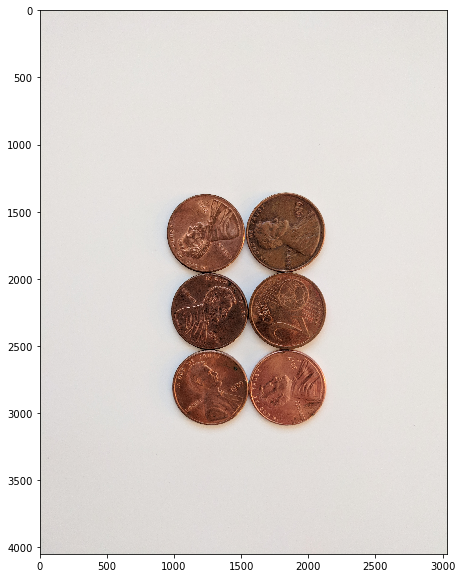

In [3]:
img_coins = cv2.imread('DATA/pennies.jpg')
rgb_coins = cv2.cvtColor(img_coins, cv2.COLOR_BGR2RGB)

show_img(rgb_coins)

# 1st try with previous knowledge

**Steps**
- 1st, BLUR (median blur) the image. Because we don't needdetails like- faces or texts on coins
- Then convert to Grayscale
- Apply Binary Threshold, in order to make it Black and White
- Find Contours

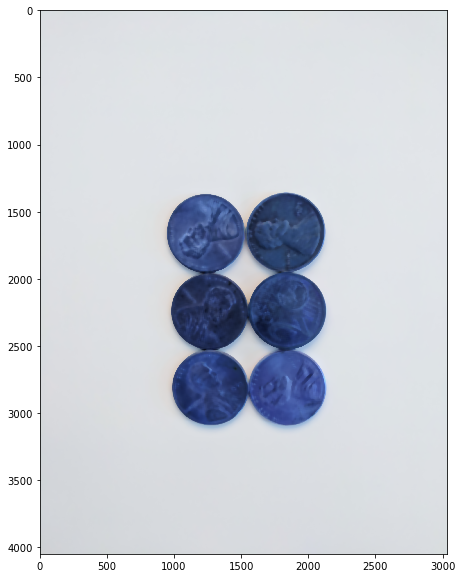

In [4]:
blur_coins = cv2.medianBlur(img_coins, 23)
show_img(blur_coins)

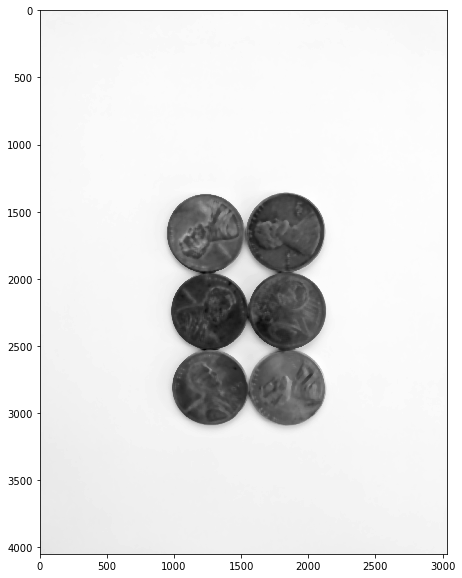

In [5]:
gray_coins = cv2.cvtColor(blur_coins, cv2.COLOR_BGR2GRAY)
show_img(gray_coins)

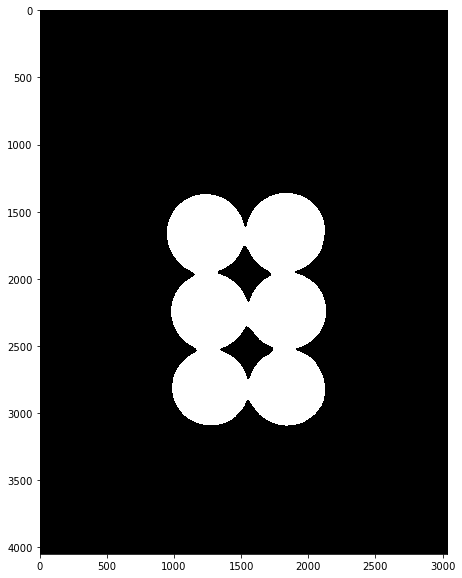

In [6]:
cutoff, thr_coins = cv2.threshold(gray_coins, 160, 255,cv2.THRESH_BINARY_INV)
show_img(thr_coins)

In [7]:
image, contours, hierarchy  = cv2.findContours(thr_coins, mode=cv2.RETR_CCOMP, method=cv2.CHAIN_APPROX_SIMPLE)

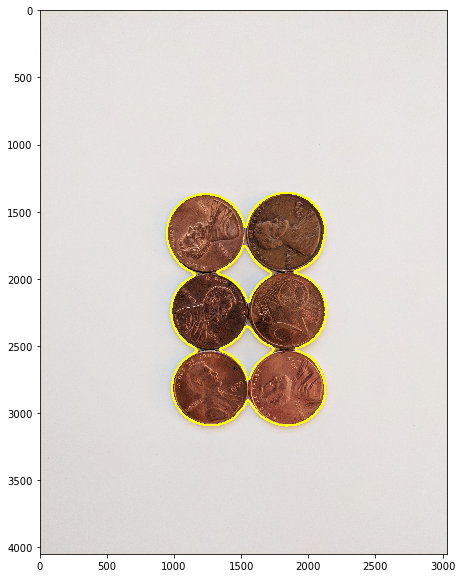

In [8]:
contour_base=rgb_coins.copy()
for i in range(len(contours)):
    
    # External Contours
#     if hierarchy[0][i][3] == -1:  # -1 = external contour
    contour_coins = cv2.drawContours(contour_base, contours, i, (255,255,0), 15)
        
show_img(contour_coins)

# Now With Watershed Algorithm

In [9]:
img_coins = cv2.imread('DATA/pennies.jpg')
rgb_coins = cv2.cvtColor(img_coins, cv2.COLOR_BGR2RGB)

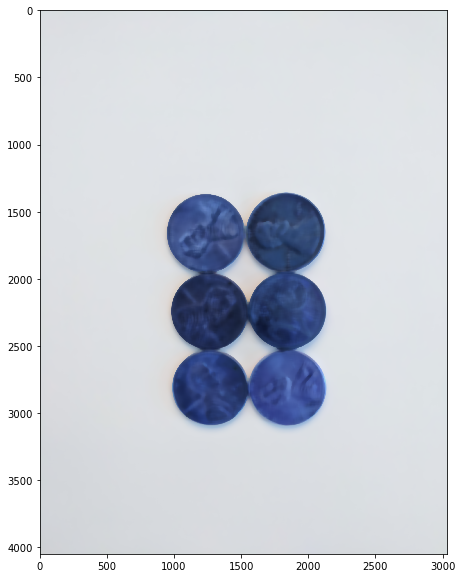

In [10]:
blur_coins = cv2.medianBlur(img_coins, 35)
show_img(blur_coins)

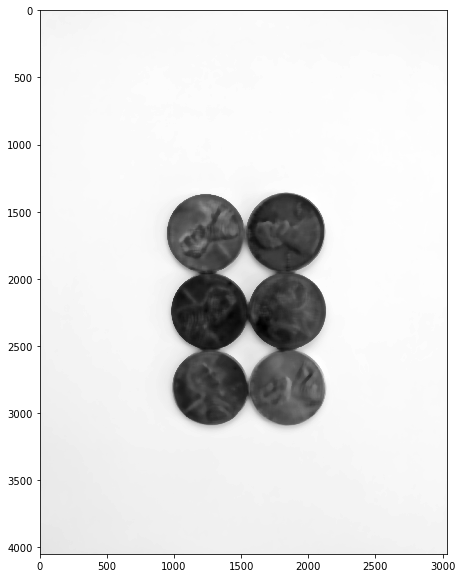

In [11]:
gray_coins = cv2.cvtColor(blur_coins, cv2.COLOR_BGR2GRAY)
show_img(gray_coins)

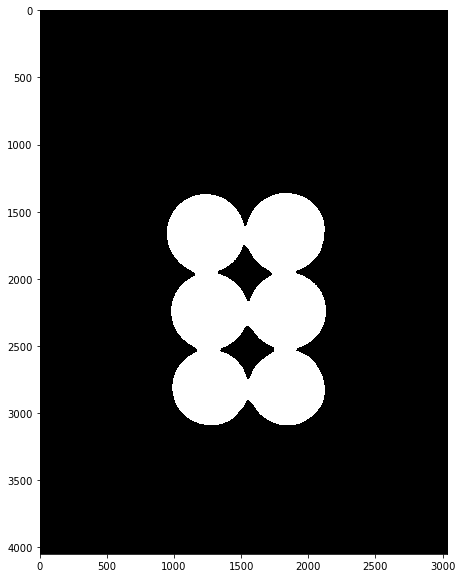

In [12]:
cutoff, thr_coins = cv2.threshold(gray_coins, 0, 255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU) # use Otsu's Method for setting threshold
show_img(thr_coins)

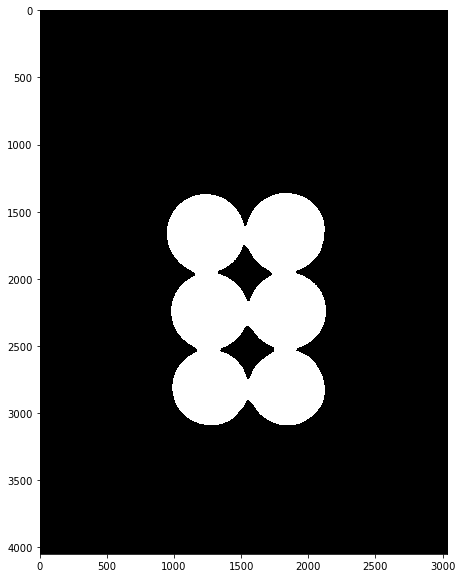

In [13]:
# Noise Reduction
kernel = np.ones(shape=(3,3), dtype=np.uint8)

opening_coins = cv2.morphologyEx(thr_coins, cv2.MORPH_OPEN, kernel, iterations=2)
show_img(opening_coins)

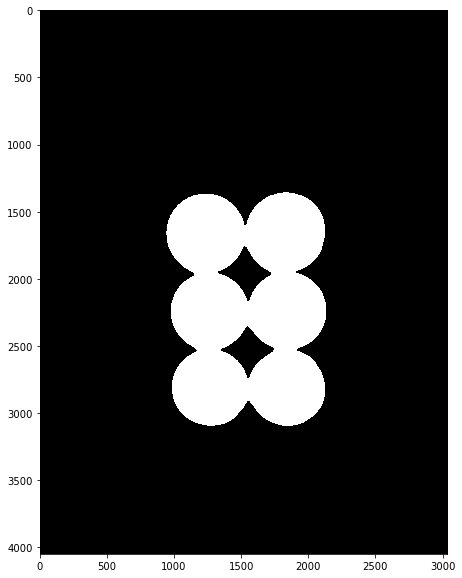

In [14]:
sure_bg = cv2.dilate(opening_coins, kernel, iterations=3)
show_img(sure_bg)

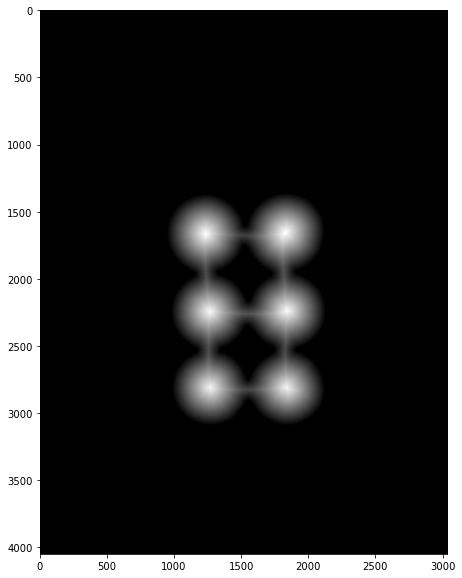

In [15]:
distance_transform_coins = cv2.distanceTransform(opening_coins, distanceType=cv2.DIST_L2, maskSize=5) # All default param values
show_img(distance_transform_coins)

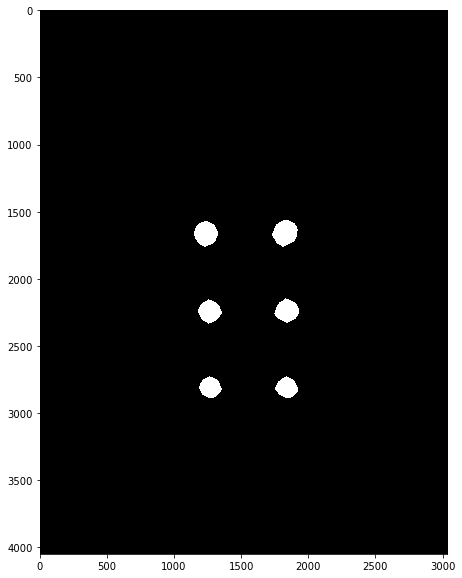

In [16]:
cutoff, sure_fg = cv2.threshold(distance_transform_coins, 0.7*distance_transform_coins.max(), 255,0)
show_img(sure_fg)

In [17]:
cutoff

201.45569763183593

In [18]:
sure_fg = np.uint8(sure_fg)

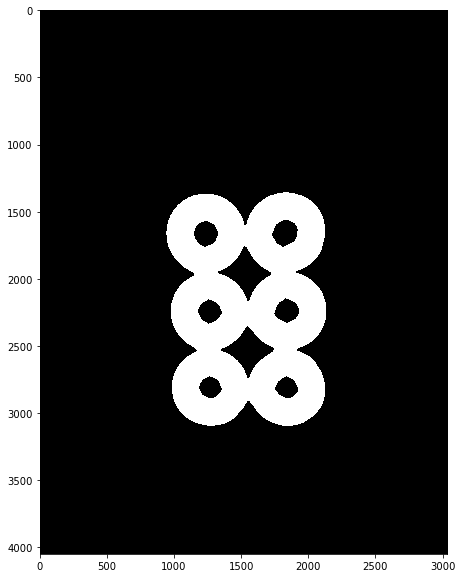

In [19]:
unknown = cv2.subtract(sure_bg,sure_fg)
show_img(unknown)

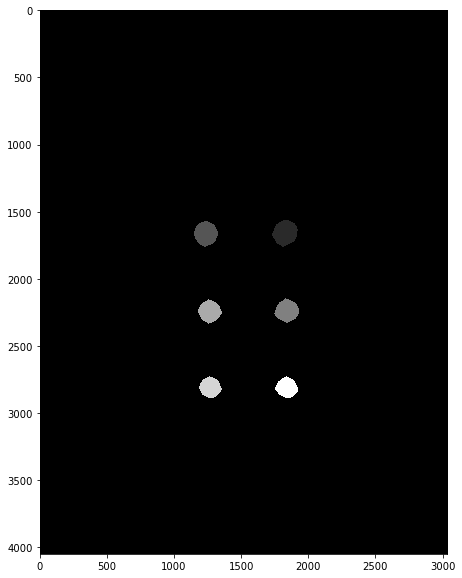

In [20]:
# Generate Markers (Seeds) for Watershed Algorithm
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers+1
show_img(markers)

In [21]:
markers[unknown==255]=0

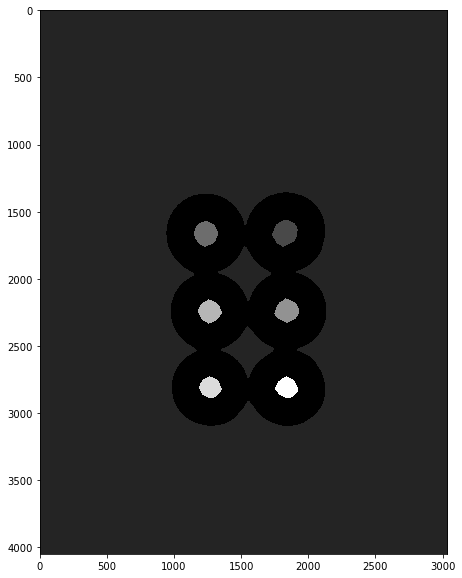

In [22]:
show_img(markers)

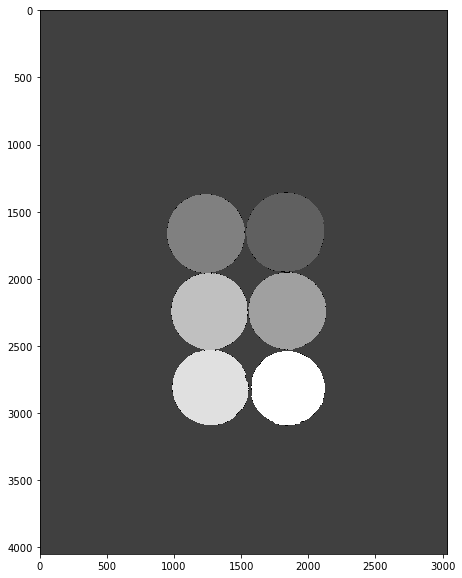

In [23]:
# Apply Watershed Algorithm to the markers
markers = cv2.watershed(img_coins, markers)
show_img(markers)

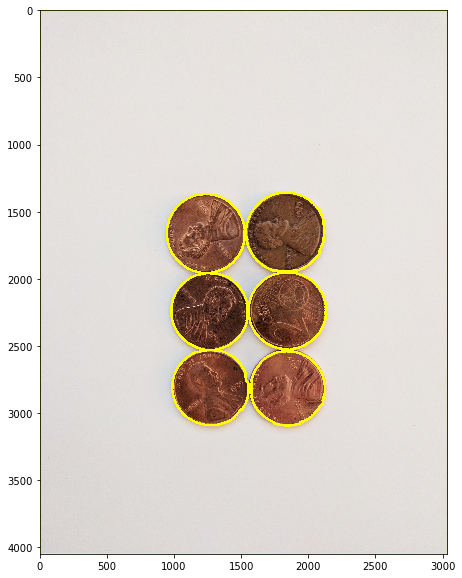

In [24]:
image, contours, hierarchy  = cv2.findContours(markers, mode=cv2.RETR_CCOMP, method=cv2.CHAIN_APPROX_SIMPLE)

contour_base=rgb_coins.copy()
for i in range(len(contours)):
    
    # External Contours
#     if hierarchy[0][i][3] == -1:  # -1 = external contour
    contour_coins = cv2.drawContours(contour_base, contours, i, (255,255,0), 15)
        
show_img(contour_coins)